# Phase I Report: Blood Cell Image Pre-processing

## Abstract
This project focuses on the pre-processing phase of blood cell image analysis. Utilizing the 'Blood Cells' dataset, the primary goal is to enhance image quality through various filtering techniques in both spatial and frequency domains. The aim is to mitigate noise, improve contrast, and sharpen features, thereby preparing the images for more accurate downstream tasks such as segmentation and classification.

## Problem Definition
Raw medical images, particularly those of blood smears, frequently suffer from issues such as low contrast, irregular illumination, and the presence of noise, which can hinder automated analysis. These imperfections make it challenging for computer vision algorithms to accurately identify and differentiate blood cell components. The objective of this pre-processing phase is to develop and apply methods that effectively address these issues, making the images more suitable for subsequent diagnostic or analytical processes by highlighting key morphological features and removing detrimental artifacts.

## Objectives

The primary objectives of this pre-processing phase are:

1.  **Noise Reduction**: Implement spatial domain filters (e.g., Gaussian smoothing, Median filtering) to reduce various types of noise (e.g., salt-and-pepper, Gaussian noise) that can obscure cellular features.
2.  **Contrast Enhancement**: Apply techniques such as Histogram Equalization and Contrast Stretching to improve the visibility of low-contrast features within the blood cell images, making boundaries and internal structures more distinct.
3.  **Feature Sharpening/Smoothing (Frequency Domain)**: Utilize frequency domain filters (e.g., Butterworth low-pass and high-pass filters) to either smooth images (remove high-frequency noise) or sharpen features (enhance high-frequency details) as required for better analysis.
4.  **Quantitative Evaluation**: Provide visual and quantitative evidence (e.g., histograms, magnitude spectrum plots) to demonstrate the effectiveness of each pre-processing technique.

In [9]:
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import kagglehub

plt.rcParams['figure.figsize'] = (12, 8)

In [10]:
dataset_path = kagglehub.dataset_download(
    'paultimothymooney/blood-cells'
)
print('Dataset extracted to:', dataset_path)

dataset_root = Path(dataset_path)
if not dataset_root.exists():
    raise FileNotFoundError(f'Dataset path not found: {dataset_root}')

print('Dataset contents:')
for entry in dataset_root.iterdir():
    print('-', entry.name)

Using Colab cache for faster access to the 'blood-cells' dataset.
Dataset extracted to: /kaggle/input/blood-cells
Dataset contents:
- dataset-master
- dataset2-master


In [3]:
def to_grayscale(image):
    if image.ndim == 3:
        return np.dot(image[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
    return image.astype(np.uint8)

def histogram_equalization(image):
    image = to_grayscale(image)
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 255))
    cdf = hist.cumsum()
    cdf_normalized = (cdf - cdf.min()) * 255 / max(cdf.max() - cdf.min(), 1)
    lut = np.round(cdf_normalized).astype(np.uint8)
    return lut[image]

def contrast_stretching(image):
    image = to_grayscale(image).astype(np.float32)
    min_val = image.min()
    max_val = image.max()
    if max_val == min_val:
        return image.astype(np.uint8)
    stretched = (image - min_val) * 255.0 / (max_val - min_val)
    return np.clip(stretched, 0, 255).astype(np.uint8)

def gaussian_kernel(size=5, sigma=1.0):
    assert size % 2 == 1, 'Kernel size must be odd'
    half = size // 2
    x = np.arange(-half, half + 1)
    y = np.arange(-half, half + 1)
    xx, yy = np.meshgrid(x, y)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def apply_filter(image, kernel):
    image = to_grayscale(image).astype(np.float32)
    pad = kernel.shape[0] // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='reflect')
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i + kernel.shape[0], j:j + kernel.shape[1]]
            output[i, j] = np.sum(region * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)

def median_filter(image, size=3):
    image = to_grayscale(image)
    pad = size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i + size, j:j + size]
            output[i, j] = np.median(patch)
    return output.astype(np.uint8)

In [1]:
def plot_histogram(image, title='Image Histogram'):
    plt.figure(figsize=(6, 4))
    plt.hist(image.flatten(), bins=256, range=(0, 255), color='gray')
    plt.title(title)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [15]:
def fft_magnitude(image):
    image = to_grayscale(image).astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log1p(np.abs(fft))
    return fft, magnitude

def butterworth_lowpass(shape, cutoff, order=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    yy, xx = np.ogrid[:rows, :cols]
    distance = np.sqrt((yy - crow)**2 + (xx - ccol)**2)
    return 1 / (1 + (distance / cutoff)**(2 * order))

def butterworth_highpass(shape, cutoff, order=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    yy, xx = np.ogrid[:rows, :cols]
    distance = np.sqrt((yy - crow)**2 + (xx - ccol)**2)
    # Avoid division by zero at the center by adding a small epsilon
    distance[crow, ccol] = 1 # Set center distance to non-zero value to avoid inf
    return 1 / (1 + (cutoff / distance)**(2 * order))

def apply_frequency_filter(image, cutoff=30, order=2, filter_type='lowpass'):
    image = to_grayscale(image).astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(image))
    if filter_type == 'lowpass':
        mask = butterworth_lowpass(image.shape, cutoff, order)
    elif filter_type == 'highpass':
        mask = butterworth_highpass(image.shape, cutoff, order)
    else:
        raise ValueError("filter_type must be 'lowpass' or 'highpass'")
    filtered = fft * mask
    inverse = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.clip(np.real(inverse), 0, 255).astype(np.uint8), mask

## Run preprocessing on a sample image
Choose a representative image from the dataset and visualize each step.

Sample image: /kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00088.jpg


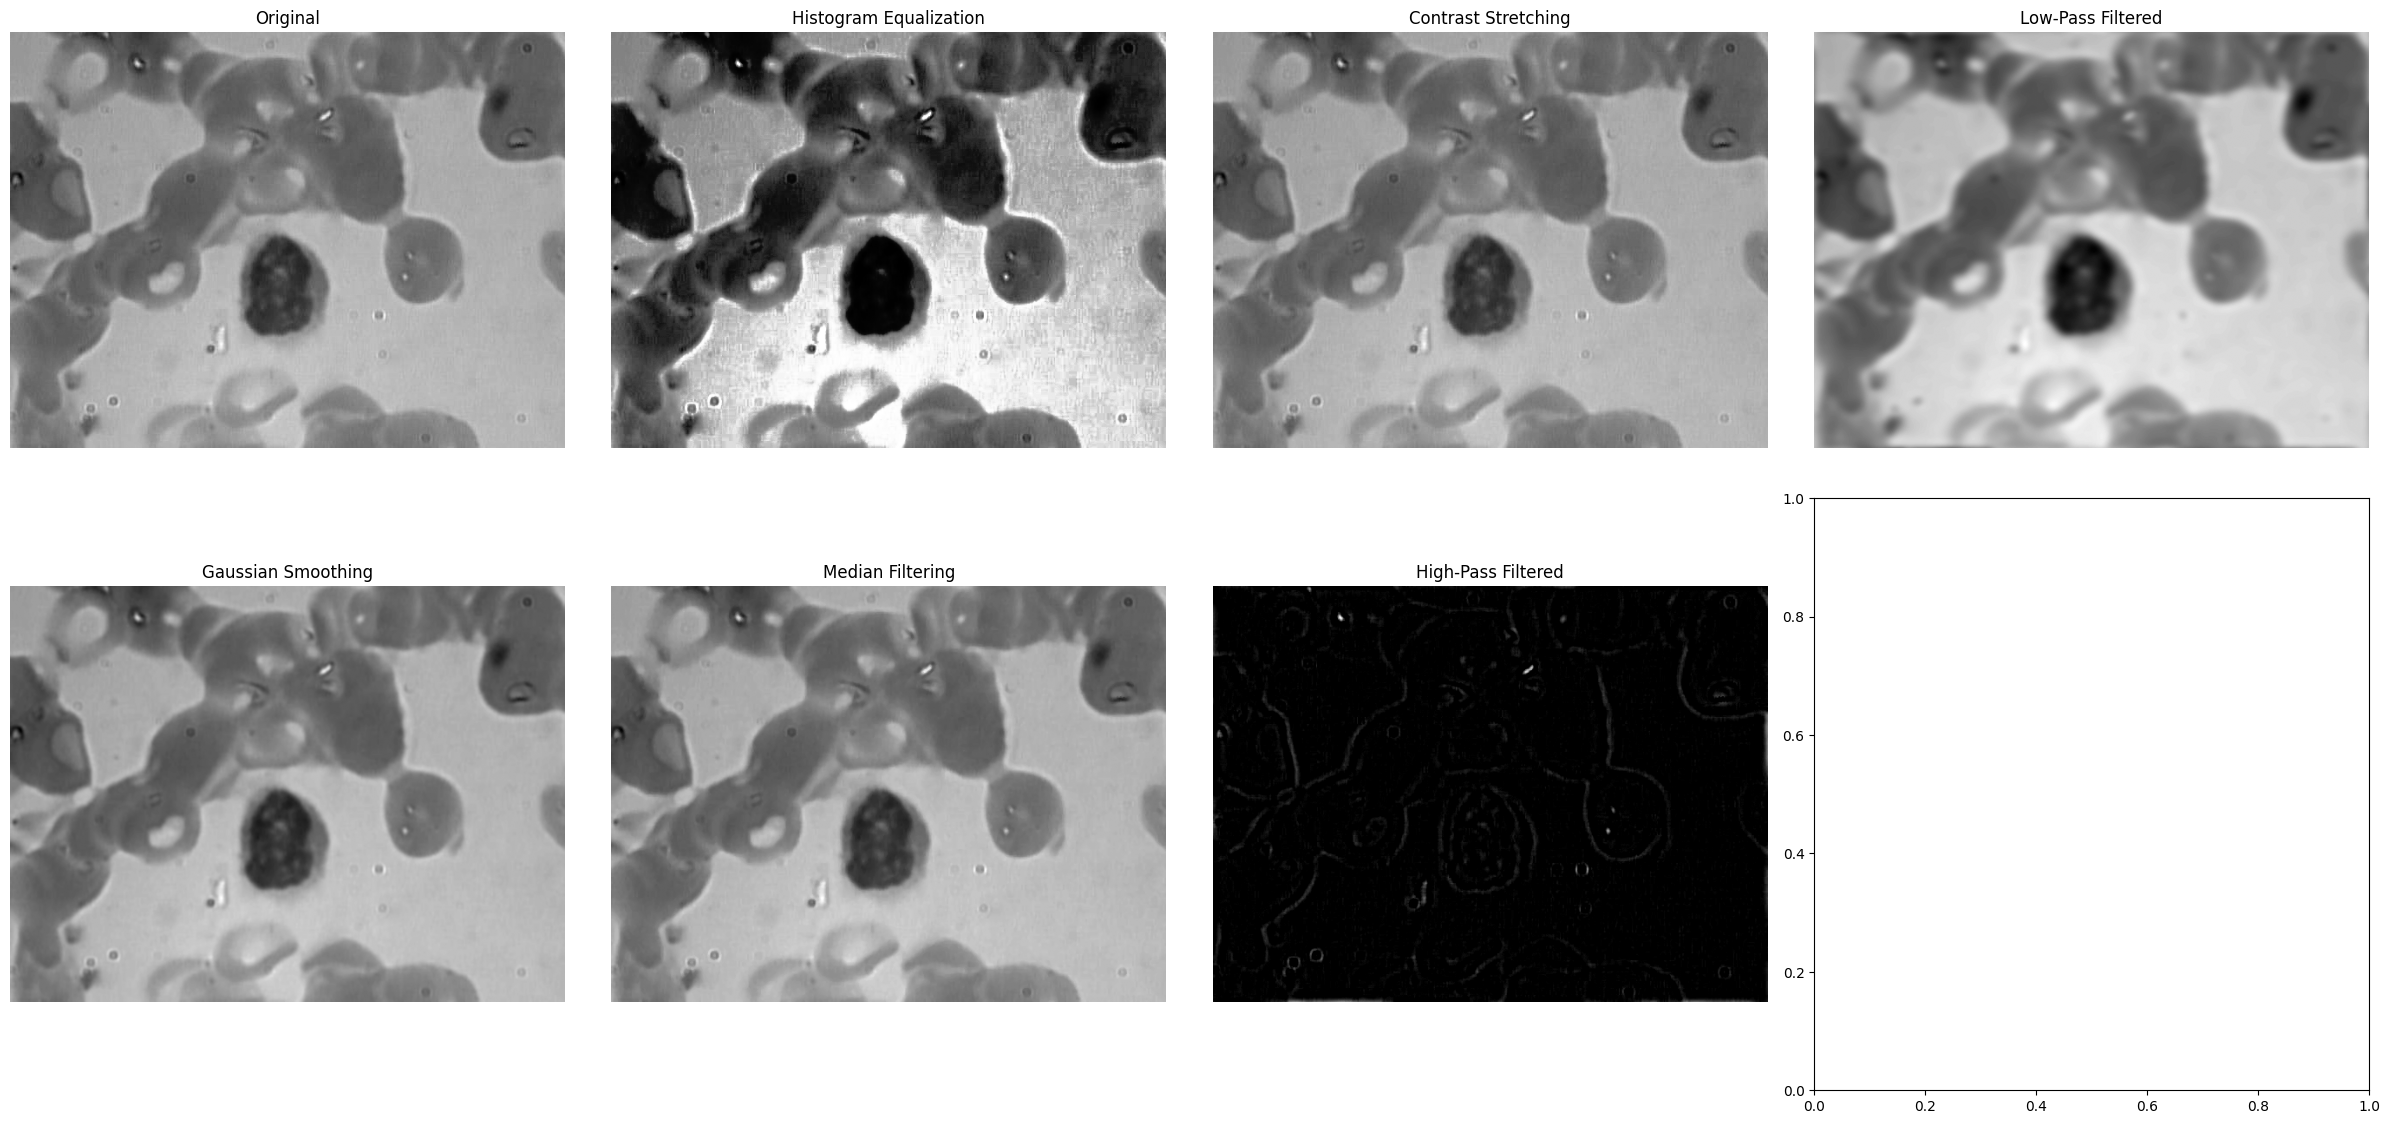

In [16]:
def find_sample_image(root):
    for cls in root.iterdir():
        if cls.is_dir():
            for path in cls.rglob('*.jpg'): # Dataset uses .jpg usually
                return path
            for path in cls.rglob('*.png'):
                return path
    raise FileNotFoundError('No sample image found in dataset')

sample_path = find_sample_image(dataset_root)
sample_image = io.imread(sample_path)
print('Sample image:', sample_path)

equalized = histogram_equalization(sample_image)
stretched = contrast_stretching(sample_image)
gauss = apply_filter(sample_image, gaussian_kernel(size=5, sigma=1.0))
median = median_filter(sample_image, size=3)
freq_lowpass_filtered, freq_lowpass_mask = apply_frequency_filter(sample_image, cutoff=30, order=2, filter_type='lowpass')
freq_highpass_filtered, freq_highpass_mask = apply_frequency_filter(sample_image, cutoff=30, order=2, filter_type='highpass')

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes[0, 0].imshow(to_grayscale(sample_image), cmap='gray'); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
axes[0, 1].imshow(equalized, cmap='gray'); axes[0, 1].set_title('Histogram Equalization'); axes[0, 1].axis('off')
axes[0, 2].imshow(stretched, cmap='gray'); axes[0, 2].set_title('Contrast Stretching'); axes[0, 2].axis('off')
axes[0, 3].imshow(freq_lowpass_filtered, cmap='gray'); axes[0, 3].set_title('Low-Pass Filtered'); axes[0, 3].axis('off')
axes[1, 0].imshow(gauss, cmap='gray'); axes[1, 0].set_title('Gaussian Smoothing'); axes[1, 0].axis('off')
axes[1, 1].imshow(median, cmap='gray'); axes[1, 1].set_title('Median Filtering'); axes[1, 1].axis('off')
axes[1, 2].imshow(freq_highpass_filtered, cmap='gray'); axes[1, 2].set_title('High-Pass Filtered'); axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

Original Image Histogram:


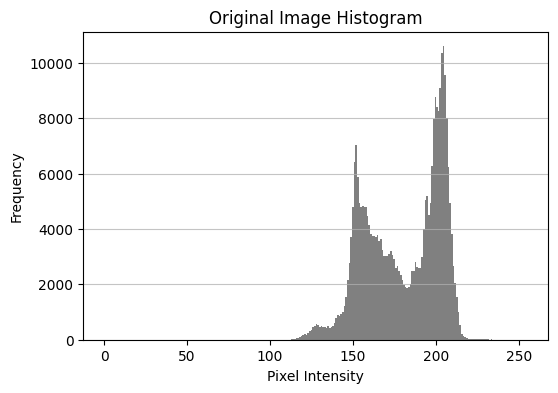

Histogram Equalized Image Histogram:


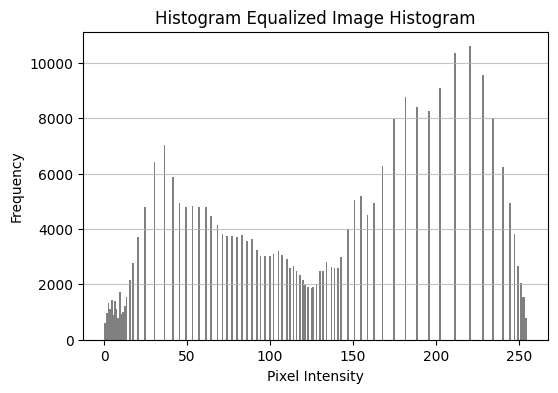

In [12]:
print('Original Image Histogram:')
plot_histogram(to_grayscale(sample_image), 'Original Image Histogram')

print('Histogram Equalized Image Histogram:')
plot_histogram(equalized, 'Histogram Equalized Image Histogram')

## Results & Interpretation

This section presents the results of applying various pre-processing techniques to a sample blood cell image and interprets their effects.

### Spatial Domain Filtering

-   **Original Image**: The baseline image, often exhibiting characteristics such as low contrast, non-uniform illumination, and noise.
-   **Histogram Equalization**: This technique redistributes pixel intensities to flatten the image histogram, often leading to a more uniform distribution of brightness and enhanced global contrast. This is evident in the 'Histogram Equalized Image Histogram' where pixel values are more spread out compared to the original, making features more discernible.
-   **Contrast Stretching**: By scaling pixel intensities to the full dynamic range (0-255), contrast stretching effectively increases the visual distinction between foreground and background. This is particularly useful for images where the significant intensity values occupy only a narrow range.
-   **Gaussian Smoothing**: A low-pass filter that blurs the image, reducing high-frequency noise and fine details. It is effective for smoothing out irregularities and preparing the image for segmentation by reducing artifacts.
-   **Median Filtering**: A non-linear filter that replaces each pixel's value with the median value of its neighbors. It is highly effective at removing salt-and-pepper noise while preserving edges better than linear filters.

### Frequency Domain Filtering

-   **Low-Pass Filtered (Butterworth)**: This filter attenuates high-frequency components, resulting in a smoothed image. It helps in removing noise and subtle textures, similar to Gaussian smoothing in the spatial domain, but can be more precisely controlled in the frequency domain. The magnitude spectrum clearly shows the attenuation of higher frequencies towards the edges after applying the low-pass filter.
-   **High-Pass Filtered (Butterworth)**: This filter enhances high-frequency components and attenuates low-frequency components, which sharpens edges and fine details while suppressing slowly varying intensity areas. The resulting image highlights boundaries and details, which is crucial for tasks like edge detection. The magnitude spectrum demonstrates the inverse effect of the low-pass filter, where central (low-frequency) components are attenuated and higher frequencies are preserved or enhanced.

**Overall Interpretation**: Each pre-processing step contributes uniquely to improving image quality for subsequent analysis. Contrast enhancement techniques make features more visible, while spatial and frequency filters address noise and emphasize relevant details. The combination of these methods provides a robust pre-processing pipeline for blood cell image analysis.

## Frequency-domain visualization
Display the magnitude spectrum before and after the Butterworth-based frequency mask.

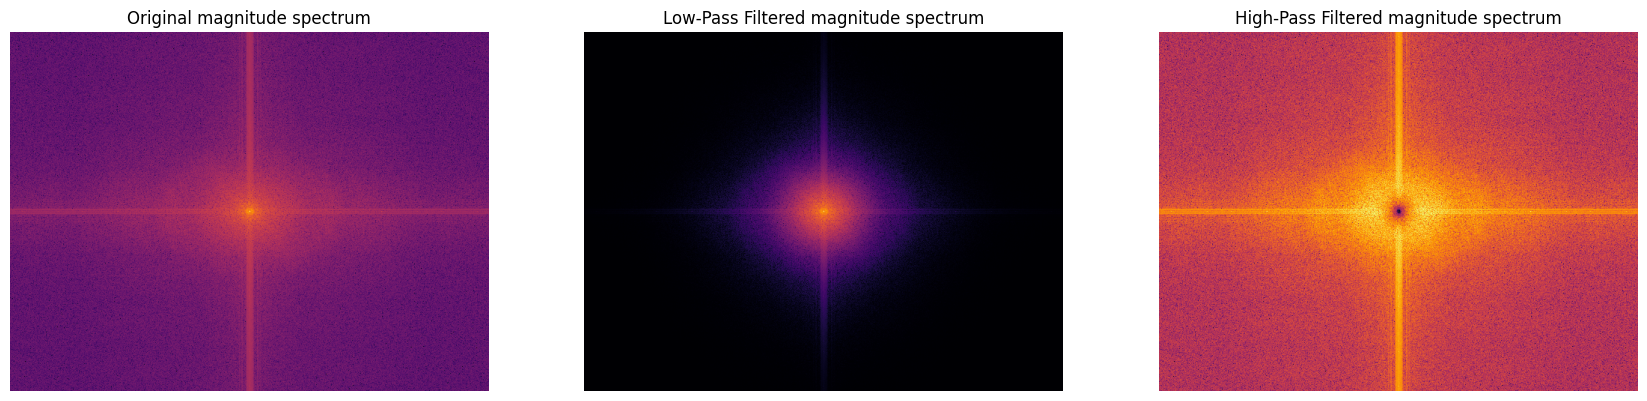

In [17]:
fft_orig, mag_orig = fft_magnitude(sample_image)

# Low-pass filter visualization
fft_lowpass_masked = fft_orig * freq_lowpass_mask
mag_lowpass_filtered = np.log1p(np.abs(fft_lowpass_masked))

# High-pass filter visualization
fft_highpass_masked = fft_orig * freq_highpass_mask
mag_highpass_filtered = np.log1p(np.abs(fft_highpass_masked))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
axes[0].imshow(mag_orig, cmap='inferno'); axes[0].set_title('Original magnitude spectrum'); axes[0].axis('off')
axes[1].imshow(mag_lowpass_filtered, cmap='inferno'); axes[1].set_title('Low-Pass Filtered magnitude spectrum'); axes[1].axis('off')
axes[2].imshow(mag_highpass_filtered, cmap='inferno'); axes[2].set_title('High-Pass Filtered magnitude spectrum'); axes[2].axis('off')
plt.show()